In [5]:
from transformer_utils import predict_next_5_days


In [9]:
import matplotlib.pyplot as plt

from data import prepare_dataset
from train import train_model
from eval import load_model, predict, compute_metrics, plot_horizon

ticker_path = "/workspace/data/AMZN.csv"

In [10]:
import os

CKPT_DIR = os.path.abspath("checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)

print("Checkpoint dir:", CKPT_DIR)


Checkpoint dir: /workspace/checkpoints


Train: (4461, 60, 6) (4461, 5)
Val:   (637, 60, 6) (637, 5)
Test:  (1275, 60, 6) (1275, 5)


Prediction shape: (1275, 5)

Scaled-space metrics:
MAE_h1: 1.401343
MAE_h2: 1.329470
MAE_h3: 1.525375
MAE_h4: 1.275489
MAE_h5: 1.425534


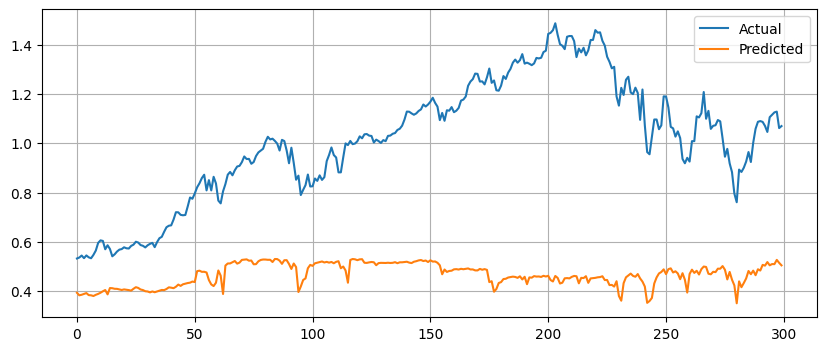

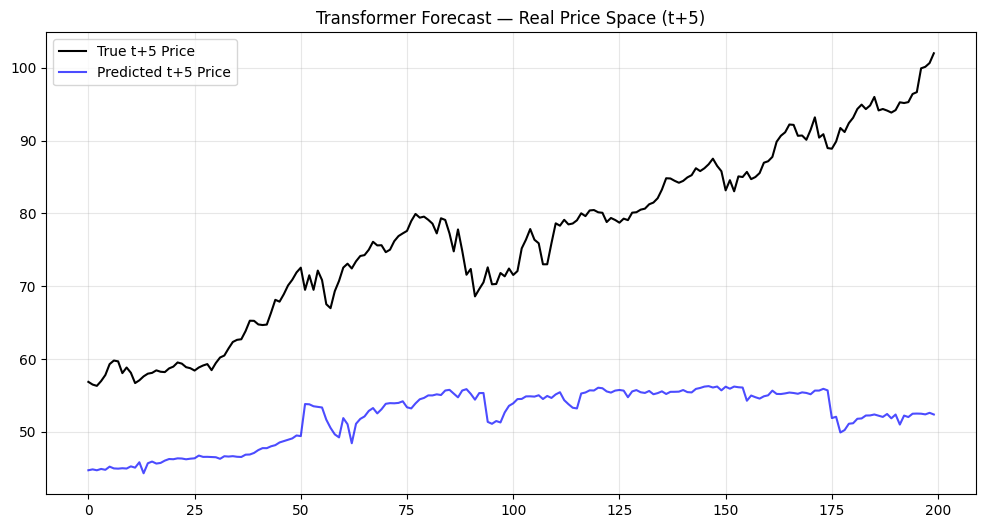


Next 5-day forecast (REAL prices):
Day +1: $50.72
Day +2: $59.76
Day +3: $43.06
Day +4: $56.34
Day +5: $52.54


In [13]:
# -------------------------------
# Setup absolute checkpoint path
# -------------------------------
# -------------------------------
# Prepare dataset
# -------------------------------
(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    scaler_X,
    close_mean,
    close_std,
) = prepare_dataset(
    ticker_path,
    seq_len=60,
    horizon=5,
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


# -------------------------------
# Train model
# -------------------------------
state = train_model(
    X_train,
    y_train,
    X_val,
    y_val,
    seq_len=60,
    out_len=5,
    batch_size=64,
    epochs=80,
    ckpt_dir=CKPT_DIR,
)


# -------------------------------
# Load best checkpoint
# -------------------------------
model, params = load_model(
    ckpt_dir=CKPT_DIR,
    seq_len=60,
    out_len=5,
    num_features=6,
)


# -------------------------------
# Predict on test set (SCALED)
# -------------------------------
y_pred = predict(model, params, X_test)

print("Prediction shape:", y_pred.shape)


# -------------------------------
# Metrics (SCALED space)
# -------------------------------
metrics = compute_metrics(y_test, y_pred)

print("\nScaled-space metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")


# -------------------------------
# Plot (SCALED space)
# -------------------------------
plot_horizon(
    y_true=y_test,
    y_pred=y_pred,
    horizon=1,
    n=300,
)

# -------------------------------
# Convert to REAL price space
# -------------------------------
y_pred_real = y_pred * close_std + close_mean
y_test_real = y_test * close_std + close_mean


# -------------------------------
# Plot (REAL price space)
# -------------------------------
plt.figure(figsize=(12, 6))
plt.plot(y_test_real[:200, -1], label="True t+5 Price", color="black")
plt.plot(y_pred_real[:200, -1], label="Predicted t+5 Price", color="blue", alpha=0.7)
plt.legend()
plt.title("Transformer Forecast — Real Price Space (t+5)")
plt.grid(alpha=0.3)
plt.show()


# -------------------------------
# Predict NEXT 5 days from last window
# -------------------------------
last_window = X_test[-1]

next_5_scaled = predict(model, params, last_window[None, :, :])[0]
next_5_prices = next_5_scaled * close_std + close_mean

print("\nNext 5-day forecast (REAL prices):")
for i, p in enumerate(next_5_prices, 1):
    print(f"Day +{i}: ${p:.2f}")


In [12]:
import numpy as np

np.save("y_test_real.npy", y_test_real)
np.save("y_pred_real.npy", y_pred_real)
np.save("next_5_prices.npy", next_5_prices)
